# Class 5: Scraping Web Data — BeautifulSoup, HTML, Pandas


Goals of today's class:
1. Finish Class 4: the configuration model
2. High-level: Learn how websites work.
3. Figure out basic principles of scraping; learn some useful tricks for scraping.
4. Turn scraped text into a network of words that appear together.
_________

## Getting today's notebook

**Every class, duplicate the notebook before you run anything, and work in the copy.** Running a cell changes the file, and a changed original can block your next pull.

1. Log in to [Open OnDemand](https://ood.explorer.northeastern.edu/), open the **Courses** menu, and click **JupyterLab (Python)**. Launch it with the same settings as last class; they should already be filled in.
2. Once JupyterLab starts, open a terminal (**File → New → Terminal**) and pull the new material, where `USERNAME` is your Northeastern username:
   ```bash
   cd /courses/NETS7052.202710/students/USERNAME/nets7052_fa26
   git fetch upstream
   git checkout main
   git merge --no-edit upstream/main
   ```
   Once you've committed work of your own to your fork (Assignment 1, for example), this merge needs a commit message. `--no-edit` lets Git write that message itself instead of opening a text editor in your terminal.
3. **Duplicate today's notebook before you run anything.** In the file browser, open `notebooks/class_05_scraping/`, right-click `class_05_scraping.ipynb`, and choose **Duplicate**. Open the copy (`class_05_scraping-Copy1.ipynb`) and work there.
4. Check that the top-right corner of the notebook says **Python (cmns-core)**. If it doesn't, choose **Kernel → Change Kernel…** and pick it.

**If the merge doesn't work:**

- *"Your local changes to the following files would be overwritten by merge"*: you changed a notebook that I've since updated, and Git lists which one. If you took notes in it, duplicate it first. Then close it and reset it, using the path Git listed:
  ```bash
  git restore notebooks/class_04_distributions/class_04_distributions.ipynb
  ```

  `git restore` throws away every change you made to that one file and puts back the version from your last pull. Git can't undo it, which is why you duplicate first. Then run `git merge --no-edit upstream/main` again.
- *"'upstream' does not appear to be a git repository"*: you missed a step in Class 0. Run this, then start again from `git fetch upstream`:
  ```bash
  git remote add upstream https://github.com/computational-methods-network-science/nets7052_fa26.git
  ```
- **Git asks for a GitHub username or password:** don't type them. Your `upstream` address is wrong. Run this, then start again from `git fetch upstream`:
  ```bash
  git remote set-url upstream https://github.com/computational-methods-network-science/nets7052_fa26.git
  ```

## Configuration model (the rest of Class 4)

Last class we stopped just before the configuration model, the last of our null models. We'll pick up from there. This section is the part of the Class 4 notebook we didn't get to.

In [1]:
# where we left off in Class 4: the karate club graph and the layout we drew it with
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
pos = nx.spring_layout(G)

In the previous two network null models, we assumed that we had access to the graph itself. How would we sample random graphs from *only the degree sequence*?

The ***configuration model*** is a method for generating random networks while preserving the degree distribution of nodes. It works by assigning "stubs" or "half-edges" to each node based on its degree and then randomly pairing these stubs to create edges. This model is often used as a null model in network analysis to study how network properties, such as clustering or motifs, arise due to the degree sequence rather than the specific arrangement of edges.

The configuration model can result in networks with self-loops and parallel edges, but these can be removed if needed to produce a simple graph. By comparing a real network to its randomized configuration model counterpart, we can gain insights into which features of the network structure are non-random and statistically significant.

(excerpt from Chapter 4 of https://networksciencebook.com/chapter/4)

![](images/figure-4-15.png)

The configuration model, illustrated in the graphic above, builds a network with a pre-defined degree sequence.

In the network generated by the model, each node has a pre-defined degree $k_i$, but otherwise the network is wired randomly. Consequently the network is often called a random network with a pre-defined degree sequence. By repeatedly applying this procedure to the same degree sequence we can generate different networks with the same $p_k$ (Image 4.15b-d). There are a couple of caveats to consider:

1. The probability to have a link between nodes of degree $k_i$ and $k_j$ is: $p_{ij}=\frac{k_i k_j}{2L-1}$. Indeed, a stub starting from node $i$ can connect to $2L - 1$ other stubs. Of these, $k_j$ are attached to node $j$. So the probability that a particular stub is connected to a stub of node $j$ is $\frac{k_j}{2L - 1}$. As node $i$ has $k_i$ stubs, it has $k_i$ attempts to link to $j$, which gives the expression for $p_{ij}$ above.

2. The obtained network contains **self-loops** and **multi-edges**, nothing in the algorithm forbids a node from connecting to itself, or to generate multiple links between two nodes. We can choose to reject stub pairs that lead to these, but if we do so, we may not be able to complete the network. Rejecting self-loops or multi-links also means that not all possible matchings appear with equal probability.

3. The configuration model is frequently used in calculations, as in the equation above, and its inherently random character helps us analytically calculate numerous network measures.

In [2]:
import networkx as nx
from collections import Counter

def configuration_model_from_degree_sequence(degree_sequence, return_simple=True):
    """
    Generate a random graph using the configuration model from a given degree sequence
    without using the NetworkX built-in function.

    The configuration model generates a random graph that preserves the degree 
    sequence of nodes by assigning "stubs" or "half-edges" to each node and 
    randomly pairing these stubs to form edges. This process can result in 
    graphs with self-loops and parallel edges, which can be removed if needed.

    Parameters
    ----------
    degree_sequence : list of int
        A list representing the degree of each node in the graph. The sum of 
        the degrees in this sequence must be even for the configuration model 
        to create a valid graph.

    return_simple : bool, optional (default=True)
        If True, merge parallel edges and remove self-loops before returning. 
        The result is a simple graph, but some of its degrees can be lower 
        than the ones in `degree_sequence`. If False, return the multigraph.

    Returns
    -------
    G : networkx.MultiGraph or networkx.Graph
        A multigraph generated from the given degree sequence. The graph may 
        contain self-loops and parallel edges, which are allowed in the 
        configuration model. With `return_simple=True`, its simple version.

    Notes
    -----
    - This method works by assigning "stubs" or "half-edges" to nodes based on 
      their degree and then randomly pairing them to form edges. The resulting 
      graph can have self-loops and parallel edges.
    - If a simple graph is required, `nx.Graph(G)` merges parallel edges, but 
      it keeps self-loops, which have to be removed separately with 
      `G.remove_edges_from(nx.selfloop_edges(G))`. Both steps lower some 
      nodes' degrees, so the simple graph no longer matches the degree 
      sequence exactly.
    - The degree sequence must have an even sum for a valid graph construction. 
      If the sum of the degrees is odd, no graph can be constructed.

    Time Complexity
    ---------------
    The time complexity is O(E), where E is the number of edges in the graph.

    Example
    -------
    >>> degree_sequence = [3, 3, 2, 2, 1, 1]
    >>> G = configuration_model_from_degree_sequence(degree_sequence)
    >>> nx.is_graphical(degree_sequence)
    True
    """

    # Check if the degree sequence is valid (sum of degrees must be even)
    if sum(degree_sequence) % 2 != 0:
        raise ValueError("The sum of the degree sequence must be even.")

    # Create stubs list: node i appears degree_sequence[i] times
    stubs = []
    for node, degree in enumerate(degree_sequence):
        stubs.extend([node] * degree)

    # Shuffle stubs to randomize the pairing process
    np.random.shuffle(stubs)

    # Initialize an empty multigraph
    G = nx.MultiGraph()

    # Add nodes to the graph
    G.add_nodes_from(range(len(degree_sequence)))

    # Pair stubs to create edges
    while stubs:
        u = stubs.pop()
        v = stubs.pop()

        # Add the edge to the graph
        G.add_edge(u, v)

    if return_simple:
        # Convert the multigraph to a simple graph. nx.Graph() merges parallel
        # edges but keeps self-loops, so we remove those separately.
        G_simple = nx.Graph(G)
        G_simple.remove_edges_from(list(nx.selfloop_edges(G_simple)))

        return G_simple

    else:
        return G

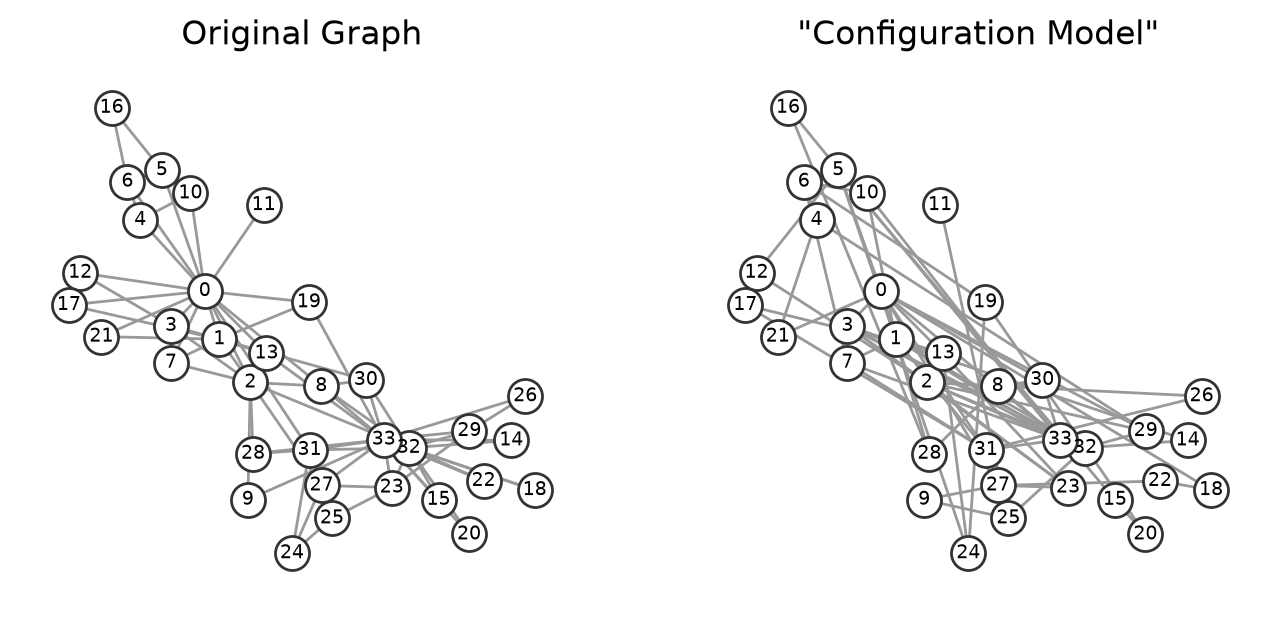

In [3]:
# A configuration-model graph with the same degree sequence as G

G_randomized = configuration_model_from_degree_sequence(list(dict(G.degree()).values()),return_simple=True)

fig, ax = plt.subplots(1,2,figsize=(8,3.5),dpi=200)

nx.draw(G, pos, node_size=150, node_color='w', edgecolors='.2',
        with_labels=True, font_size='x-small', edge_color='.6', ax=ax[0])
ax[0].set_title("Original Graph")

nx.draw(G_randomized, pos, node_size=150, node_color='w', edgecolors='.2',
        with_labels=True, font_size='x-small', edge_color='.6', ax=ax[1])
ax[1].set_title('"Configuration Model"')


# plt.savefig('images/pngs/null_models_configurationmodel.png', dpi=425, bbox_inches='tight')
# plt.savefig('images/pdfs/null_models_configurationmodel.pdf', bbox_inches='tight')

plt.show()

__________
#### Supplemental Math

Notice that the inherent randomness of the networks generated using the configuration model allows the analytical calculation also of properties such as the clustering coefficient and the average shortest path in the general case of random uncorrelated graphs with given degree distribution $P(k)$. 

For instance, the general expression for the **average clustering coefficient** reads as:

$$ \left\langle C \right\rangle = \frac{1}{N} \frac{\left(\left\langle k^2 \right\rangle - \left\langle k \right\rangle\right)^2}{\left\langle k \right\rangle^3}.$$

This implies that the clustering properties have an intrinsic dependence on the degree distribution moments. In the limit of infinite size $N \rightarrow  \infty$, the clustering coefficient is null as expected in a completely random graph. However, in finite size networks with large fluctuations of the degree distribution, the clustering coefficient could have much larger values than in the case of the Poissonian Erdős–Rényi graph because of the large values attained by $\left\langle k^2\right\rangle$.

A generalization of the formula for the scaling of the **average shortest path** of the graph can similarly be obtained and reads:

$$ \left\langle l \right\rangle \simeq 1 + \frac{\log\left(N / \left\langle k \right\rangle\right)}{\log\left(\left(\left\langle k^2 \right\rangle - \left\langle k \right\rangle\right)/\left\langle k \right\rangle\right)}.$$

_________________

## How do websites work?

### What is the "backend" of a website?
The backend of a website has a bunch of moving parts. Content probably lives in a database (or, more likely these days, several databases). There are servers (big computers) with functions that are responsible for getting content from the databases and sending it, in a machine-readable format, to the frontend. This functionality is called an API, or *Application Programming Interface*. It is (generally speaking) how computers request and get data. 

### What is the "frontend" of a website?
The frontend of a website is where you, the human user, see the content. The frontend takes the big chunk of content sent from the server via the API and puts it into a nice, pretty format. This is what you see as "the website." The way that websites typically display content is via a combination of HTML (hypertext markup language) templates and Javascript, for the interactive features. 

#### HTML
HTML is a programming language that people use to make webpages. It consists of *elements* that can be nested within each other. Elements are indicated with *tags;* typically there are open tags (`<p>`) and close tags (`</p>`) that surround the contents of an element. Browsers read HTML and use the tags to figure out how to display content; you don't see the raw HTML when you use a browser (though you can do so using the "inspect element" feature). Here is an example of a (very bare-bones) HTML file:
```
<!DOCTYPE html>
<html>
<head><h1>This is a header!</h1></head>
<body>

<h2>This is a heading!</h2>

<p>And this is a paragraph</p>

</body>
</html>
```
Let's see what this looks like in our notebook!

In [4]:
from IPython.display import display, HTML

my_html_string = """
<!DOCTYPE html>
<html>
<head><h1>This is a header!</h1></head>
<body>

<h2>This is a heading!</h2>

<p>And this is a paragraph</p>

</body>
</html>
"""
display(HTML(my_html_string))

Here's an example with a link and an image:

In [5]:
now_with_link = """
<!DOCTYPE html>
<html>
<head><h1>This has a link!</h1></head>
<p>
<a href="https://northeastern.edu">This is a link</a>
</p>
<img src="images/whale.jpg" alt="this is a whale" width=200 height=200>
"""
display(HTML(now_with_link))

Obviously most websites are more fancy than that, but at their core, when you visit them, HTML is being generated -- and you can look at it with your computer instead of via your browser. 
The act of looking at web pages via your computer (i.e. programmatically) instead of via a conventional browser is called *scraping*, and it's not super hard to do!

## Ways to access a website
### Visiting the website via a browser 
Pros: 
* Does not require that much specialized knowledge.
* Is how you're generally encouraged to use websites.
* Easy to understand what you're looking at.

Cons:
* Does not scale well (if you're trying to look at 5000 webpages, this is not a good approach)

### Using a website's API
Pros:
* Much faster
* Scales better
* Output is easily machine-readable

Cons:
* The API exists because the website's owner allows it to exist (see: Twitter/X). 
* Might cost money
* Might have rate limits
* Output is not easy to read if you are a human

### Scraping a website
Pros:
* Also scales pretty well
* Does not require the goodwill of a website's owner
* Scraping publicly accessible data is [legal](https://techcrunch.com/2022/04/18/web-scraping-legal-court/) in the US

Cons:
* You run the risk of getting your IP banned
* Often have to build a custom scraper for each website
* Not doable for all websites (e.g. Facebook)

## How do we scrape a website?

### First, we practice good robot citizenship via the `robots.txt` file!
https://en.wikipedia.org/wiki/Robots_exclusion_standard

https://www.robotstxt.org/robotstxt.html

- It is a standard used by websites to communicate with web crawlers and other web robots
- The standard specifies how to inform the web robot about which areas of the website should not be processed or scanned
- Robots are often used by search engines to categorize web sites
- Not all robots cooperate with the standard; email harvesters, spambots, malware, and robots that scan for security vulnerabilities may even start with the portions of the website where they have been told to stay out

In practice,
- when a site owner wishes to give instructions to web robots they place a text file called robots.txt in the root of the web site hierarchy (e.g. https://www.example.com/robots.txt)
- this text file contains the instructions in a specific format
- robots that choose to follow the instructions try to fetch this file and read the instructions before fetching any other file from the web site
- if this file doesn't exist, web robots assume that the web owner wishes to provide no specific instructions, and crawl the entire site.
- a robots.txt file covers one origin. For websites with multiple subdomains, each subdomain must have its own robots.txt file.

### Let's check out the `robots.txt` for Northeastern's course catalog using the `requests` package.
The `requests` package lets us make requests to websites or APIs. It gives us back HTML webpages that we can read through as if they were .html files. 

In [6]:
import requests
res = requests.get('https://catalog.northeastern.edu/robots.txt')
print(res.text)

Sitemap: https://catalog.northeastern.edu/sitemap.xml
User-agent: *
Disallow: /archive/
Disallow: /admin/
Disallow: /pagewiz/
Disallow: /courseleaf/
Disallow: /wiztest/
Disallow: /navbar/
Disallow: /gallery/
Disallow: /clmail/
Disallow: /dbleaf/
Disallow: /depts/
Disallow: /responseform/
Disallow: /mig/
Disallow: /tmp/
Disallow: /ribbit/
Disallow: /azindex/
Disallow: /catalogcontents/
Disallow: /shared/
Disallow: /cim/
Disallow: /courseadmin/
Disallow: /programadmin/
Disallow: /miscadmin/
Disallow: /js/
Disallow: /images/
Disallow: /css/
Disallow: /styles/
Disallow: /search/
Disallow: /xsearch/
Disallow: /migration/
Disallow: /fonts/
Disallow: /pdf/
Disallow: /wen/
Disallow: /graduate/engineering/multidisciplinary/user-experience-design-graduate-certificate/
Disallow: /graduate/health-sciences/nursing/dnp-concentration-nurse-anesthesia/
Disallow: /graduate/engineering/multidisciplinary/full-stack-software-engineering-graduate-certificate/
Disallow: /graduate/engineering/multidisciplina

Our `User-agent` is categorized under `*`, so we're not allowed to look at a bunch of different pages, as listed above. That's okay, though, because we're allowed to look at `/course-descriptions`. 

## Actually Scraping Data
Now we're going to walk through the process of crawling Northeastern's course catalog a bit. We'll start by looking at some real HTML and discuss parsing it. 

In [7]:
# Scraping the main catalog page
catalog_res = requests.get('https://catalog.northeastern.edu/course-descriptions/')
catalog_html = catalog_res.text

# Displaying the first 2,000 characters of the raw HTML (the whole page is much longer)
catalog_html[:2000]

'\n\n<!doctype html>\n<html class="no-js" xml:lang="en" lang="en" dir="ltr">\n\n<head>\n<meta http-equiv="X-UA-Compatible" content="IE=Edge" />\n<title>Course Descriptions &lt; Northeastern University Academic Catalog</title>\n<meta http-equiv="Content-Type" content="text/html; charset=utf-8" />\n<meta property="og:site_name" content="Northeastern University Academic Catalog" />\n<link rel="search" type="application/opensearchdescription+xml"\n\t\t\thref="/search/opensearch.xml" title="Catalog" />\n<meta name="viewport" content="width=device-width, initial-scale=1.0, minimum-scale=1.0" />\n<link href="/favicon.ico" rel="shortcut icon" />\n<link rel="stylesheet" type="text/css" href="/css/reset.css" />\n<link rel="stylesheet" type="text/css" href="//fonts.googleapis.com/css?family=Roboto:400,400i,500,500i,700,700i">\n<link rel="stylesheet" type="text/css" href="//fonts.googleapis.com/css?family=Lato:300,300i,400,400i,700,700i,900">\n<link rel="stylesheet" type="text/css" href="/fonts/fo

Wow! That's really hard to read if you're a human! We're going to use the `BeautifulSoup` Python package to parse the HTML that we just got. Parsing HTML on your own is not something I recommend; there are already tools that do it correctly, and writing the [regular expressions](https://www.regular-expressions.info/) to navigate the tree structure of HTML is simply not worth your time. 

In [8]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(catalog_html, 'html.parser')  # name the parser, or BeautifulSoup guesses and warns
print(soup.prettify()[:3000])

<!DOCTYPE html>
<html class="no-js" dir="ltr" lang="en" xml:lang="en">
 <head>
  <meta content="IE=Edge" http-equiv="X-UA-Compatible"/>
  <title>
   Course Descriptions &lt; Northeastern University Academic Catalog
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <meta content="Northeastern University Academic Catalog" property="og:site_name"/>
  <link href="/search/opensearch.xml" rel="search" title="Catalog" type="application/opensearchdescription+xml"/>
  <meta content="width=device-width, initial-scale=1.0, minimum-scale=1.0" name="viewport"/>
  <link href="/favicon.ico" rel="shortcut icon"/>
  <link href="/css/reset.css" rel="stylesheet" type="text/css"/>
  <link href="//fonts.googleapis.com/css?family=Roboto:400,400i,500,500i,700,700i" rel="stylesheet" type="text/css"/>
  <link href="//fonts.googleapis.com/css?family=Lato:300,300i,400,400i,700,700i,900" rel="stylesheet" type="text/css"/>
  <link href="/fonts/font-awesome/font-awesome.min.css" re

### Reading HTML with BeautifulSoup
As you can see, `BeautifulSoup` puts the HTML in a much neater format. We can also use it to programmatically navigate the HTML document we're seeing. Let's open up the [course catalog](https://catalog.northeastern.edu/course-descriptions/) in our browser and use the "inspect element"/"inspect" tool in our browser to see exactly which parts of the HTML are responsible for important chunks of the content we're seeing.

Right-click on the title ("Course Descriptions") and use the menu that appears to open up the inspect tool. Here's what this looks like in Firefox:

![Screenshot of Firefox inspect element](images/inspect_course_description_lesson_5.png)

We know that the element containing the large words "Course Descriptions" is an `h1` element (header font) wrapped in a div whose ID is `site-title`. `div` tags denote separate divisions or sections within an HTML document. Let's use BeautifulSoup to find this particular element and see what's nested inside it:

In [9]:
site_title_div = soup.find('div', id="site-title")
print('this is the entire div in question:')
print(site_title_div)
print('\n and this is the H1 element:')
print(site_title_div.h1)
print('\n and here is the text we actually see in our browser:')
print(site_title_div.h1.string.strip())

this is the entire div in question:
<div id="site-title">
<div class="wrap">
<h1>
                Course Descriptions
            </h1>
</div>
</div>

 and this is the H1 element:
<h1>
                Course Descriptions
            </h1>

 and here is the text we actually see in our browser:
Course Descriptions


We can use BeautifulSoup to navigate the HTML document! Let's try looking at a bunch of links and play around with navigating them. Specifically, we're going to look at the different departments with courses listed in the course catalog. Let's start by inspecting the first linked department, Accounting:

![inspecting the element containing the link to Accounting](images/accounting_inspect_course_5.png)

________

The department links appear to be nested inside a div whose ID is `atozindex`. Inside this div, if we scroll through the inspector console, we'll see a bunch of `ul` elements (`ul` makes an unordered (bulleted) list) alternating with `h2` elements, one each for each letter of the alphabet.

![The ul and h2 elements for the alphabetical department listings](images/alphabetical_div_inspect_course_5.png)
_____________

Let's pull out the div we're interested in and look at all the `ul` elements nested inside it. Inside each `ul` are the links to all the departments starting with a particular letter. 

In [10]:
soup_alpha_div = soup.find('div', id="atozindex")
print('This is the first ul element:')
first_ul = soup_alpha_div.find('ul')
print(first_ul)
print('\n And this is the first list (li) element within the list:')
first_bullet = first_ul.find('li')
print(first_bullet)
print('\n Finally, we can get the link and its href (the partial URL that points to the accounting courses):')
print(first_bullet.a.get('href'))

This is the first ul element:
<ul>
<li><a href="/course-descriptions/acct/">Accounting (ACCT)</a></li>
<li><a href="/course-descriptions/acc/">Accounting - CPS (ACC)</a></li>
<li><a href="/course-descriptions/avm/">Advanced Manufacturing Systems - CPS (AVM)</a></li>
<li><a href="/course-descriptions/afcs/">Africana Studies (AFCS)</a></li>
<li><a href="/course-descriptions/amsl/">American Sign Language (AMSL)</a></li>
<li><a href="/course-descriptions/aly/">Analytics - CPS (ALY)</a></li>
<li><a href="/course-descriptions/anth/">Anthropology (ANTH)</a></li>
<li><a href="/course-descriptions/ant/">Anthropology - CPS (ANT)</a></li>
<li><a href="/course-descriptions/aai/">Applied Artificial Intelligence - CPS (AAI)</a></li>
<li><a href="/course-descriptions/apl/">Applied Logistics - CPS (APL)</a></li>
<li><a href="/course-descriptions/arab/">Arabic (ARAB)</a></li>
<li><a href="/course-descriptions/arch/">Architecture (ARCH)</a></li>
<li><a href="/course-descriptions/army/">Army ROTC (ARMY)<

If we want to get all items matching a description, we use the `find_all` function. Let's look at all the bulleted lists of departments and get the links that point to their courses:

In [11]:
department_hrefs = []
for ul in soup_alpha_div.find_all('ul'):
    for li in ul.find_all('li'):
        department_hrefs.append(li.a.get('href'))

We can use these hrefs (which are partial URLs) to navigate programmatically to a specific department's courses. Let's pick a random department href and navigate to its course descriptions:

In [12]:
import random
my_href = random.choice(department_hrefs)

my_full_url = 'https://catalog.northeastern.edu' + my_href
print(my_full_url)
dept_html = requests.get(my_full_url).text

https://catalog.northeastern.edu/course-descriptions/ins/


### Break

## Scraping Course Descriptions
Using the URL for your randomly selected department and the skills you've just learned, see if you can gather up some course titles and descriptions. What would be a good way to store this data? Does your answer change if you just need to plug the data into a function versus needing to send the data to a colleague?

In [13]:
# Your Turn!
def get_course_titles_and_descriptions(dept_html):
    """
    Given a string of raw html (dept_html) that contains a department's course titles and descriptions,
    return a useful data structure that contains only the titles and descriptions. 
    """
    pass

### Bonus Fun:
Can you find the links to the prerequisites for a course in your data structure and retrieve *the prerequisites' descriptions* if they are in the same department?

## Word Frequency & Co-Occurrence
We have functionality to obtain course descriptions, so let's put it to use. For a particular department's course listings, let's look at what words they use most often. To do this, we'll make use of two neat tricks: the `split` method for strings and `collections.Counter`. 

To split up a string by any delimiter, we can use `split`. By default, `my_string.split()` will split a string at space characters, returning a list of the chunks that were separated by space characters before. If you want to use a different delimiter, like a comma, you can use `my_string.split(",")`. Delimiters can also be more than one character; a common one is a comma followed by a space. Additionally, if you have extra whitespace on either side of a string after you split it up, you can use `my_chunk.strip()` to strip leading & trailing whitespace. 

We'll also want to make sure that uppercase versions of a word are indexed the same as lowercase versions of the same word, so we'll use `my_string.lower()` to make sure all words are in lowercase. 

And recall that `collections.Counter` can count up how many instances of each unique item shows up in an iterable (like a list). 

In [14]:
my_string = "whale dolphin fish shark"
print(my_string.split())
my_other_string = "whale,dolphin,fish,shark"
print(my_other_string.split(','))
my_next_string = "whale, dolphin, fish, shark"
print(my_next_string.split(', '))

my_string_with_spaces = '  whale '
print('my string is ' + my_string_with_spaces)
print('my string is ' + my_string_with_spaces.strip())

uppercase_string = "WHALE"
print(uppercase_string.lower())

['whale', 'dolphin', 'fish', 'shark']
['whale', 'dolphin', 'fish', 'shark']
['whale', 'dolphin', 'fish', 'shark']
my string is   whale 
my string is whale
whale


### Word Frequency
Now we'll write a function that takes the output of the last function you wrote, `get_course_titles_and_descriptions`, and returns a dict of word frequencies. We'll also remove *stopwords*, which are words that are so commonly used they don't tell us much about the text. These are words like "an", "and", "the", "than", etc. (We sourced our stopwords from [this repo](https://github.com/stopwords-iso/stopwords-en)). Can you make a bar chart of the top 10 most frequently used words in your list of course descriptions?

In [15]:
# Your Turn!
STOPWORDS = set()
with open('data/stopwords-en.txt', 'r') as f:
    for line in f.readlines():
        STOPWORDS.add(line.strip())
        
def get_word_frequencies_from_all_course_descriptions(course_descriptions):
    """
    Given a list of course descriptions, return a dict of word usage frequencies. 
    
    Input: course_descriptions, a list of strings
    Output: word_freqs, a dict mapping words (lowercased) to integer frequency counts.
    """
    pass

In [16]:
# Your Turn Again!
import matplotlib.pyplot as plt

# plt.bar(top_ten_words, top_ten_word_counts)

### Word Co-Occurrence
Another interesting thing we can do is create a data structure for word co-occurrence -- which words show up in the same course description a lot of the time? Given that same list of course descriptions, let's create a data structure that keeps track of which words appear frequently in the same description. I recommend using a matrix or a nested dictionary; both have upsides and drawbacks. Which pair of words occurs together the most frequently?

In [17]:
# Your Turn!
def get_word_co_occurrences_from_all_course_descriptions(course_descriptions):
    """
    Given a list of course descriptions, return a data structure with word co-occurrence counts.
    
    Input: course_descriptions, a list of strings
    Output: a data structure of your choice indicating word co-occurrences.
    """
    pass

### From co-occurrence to a network
Now let's turn those counts into a network. Make each word a node, and link two words when they appear in the same course description, with the number of descriptions they share as the edge's `weight`. Which words have the highest weighted degree, `G.degree(weight='weight')`? What changes if you keep only the pairs that appear together in at least a few descriptions?

In [18]:
# Your Turn!
import networkx as nx


__________
## Next time...
Data Science & SQL! `class_06_data_science_sql.ipynb`
_______

## References and further resources:

1. Class Webpages
    - Jupyter Book: https://computational-methods-network-science.github.io/nets7052_fa26/README.html
    - Github: https://github.com/computational-methods-network-science/nets7052_fa26/
    - Syllabus and course details: https://brennanklein.com/nets7052-fall26
2. [A more in-depth view on how websites work](https://www.freecodecamp.org/news/how-the-web-works-a-primer-for-newcomers-to-web-development-or-anyone-really-b4584e63585c/)
3. The description of the `robots.txt` file we use in this lesson comes from [Dr. Matteo Chinazzi](https://www.matteochinazzi.com/) and [Dr. Qian Zhang's](https://www.zhangqianrach.org/) 2018 rendition of this course.
4. [Selenium](https://www.selenium.dev/) is a package that lets you programmatically simulate using a browser to scrape and interact with websites; it's handy for interacting with the Javascript elements of websites, for example. 

5. [nltk](https://www.nltk.org/), or the Natural Language Toolkit, is a Python package for cleaning and parsing text (natural language) data. If you're interested in diving into natural language processing more, NLTK is a great first step.

6. [More on co-occurrence matrices](https://www.baeldung.com/cs/co-occurrence-matrices)